# Lab 6

In [1]:
### MATPLOTLIB SETUP ###
import math
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
#Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Prelab

The first step is to find our desired turns ratio for our transformer, whch we did using the equation

$$a = \frac{V_o}{V_g} \cdot \frac{\sqrt{\alpha}-D}{D}$$

with the prelab parameters of a desired input of 18V, output of 10V, $\alpha$ of 0.7, and duty cycle of 0.35. This calculation is performed in the below code cell

In [2]:
Vo = 10

## DESIRED a
alpha_want = 0.7
D_want = 0.35
a_want = (Vo/VG) * ((sqrt(alpha_want) - D_want)/(D_want))

V = Vo/a_want
Ri = R/a_want**2
M_want = Vo / (a_want * VG)
M_want, a_want

(0.7191878948691365, 0.772476232593771)

Next, using the equation for a buck-boost converter, we found the peak current with this configuration (ensuring to use the flyback to buck-boost transformed output resistance and output voltage), and found it to be about 6.35A

In [3]:
Ipk_want = (2/sqrt(alpha_want)) * (M_want+1) * V/Ri
Ipk_want

6.349206349206349

Next, using the we found the critical inductance and multiplied by our desired alpha of 0.7 to find our target inductance of about 19.6 uH. Similarly, we modeled the flyback as a buck-boost and transformed M and $\alpha$

In [4]:
Lcrit = (1/(M_want+1))**2 * (Ri) * (Ts/2)
L_target = Lcrit * alpha_want
print(f"Target inductance: {L_target}") # target inductance

Target inductance: 1.9648514851485144e-05


Next, we started to design our transformer. We first found the minimum number of turns with the same equation we used when designing our inductor in the code cell below (but note the higher Bmax!) to be just above 7 (so we treated 8 as our starting point).

In [5]:
Bmax = 0.3 # 300mT, given in worksheet
Ac = 59.1 / 10e5 # Found in core datasheet

L = 14e-6

max_flux = Bmax * Ac
min_turns = (L_target*Ipk_want) / (max_flux) 
print(f"Minimum turns: {round(min_turns, 3)}")

Minimum turns: 7.036


However, knowing our desired turns ratio was about 0.77, we opted for a 9 and 7 turn configuration, which would put very close to our desired turn ratio of 0.77 as opposed to something like 8 and 6 or 10 and 8.

In [6]:
n1 = math.ceil(min_turns+1) # winding 1 turns
n2 = round(a_want * n1) # winding 2 turns
a = n2/n1

print(n1, n2, a)

9 7 0.7777777777777778


Next, we calculated the magnetizing inductance using the equation

$$L = N^2 * P$$

where

$$P = \frac{A_{eq} * \mu_0}{l_g}$$

In this case, we are approximating equivalent gap length as physical gap length, and approximating equivalent gap area by adding a band of the air gap-length around the core area plus the bobbin order. $\mu_0$ refers to the permeability of free space. Looking in increments of the shim lengths available to us, we found that under the 9/7 turn ratio, using 10 mils of shim got us closest to our target magnetizing inductance. With this 19.3 uH number, we then calculated our estimated alpha (0.68) and duty cycle (38%) to ensure we were meeting the specified parameters.

In [7]:
lg = 10 # user defined (mils)
lg *= 0.0254 # to mm

x1 = 7+lg
x2 = 9-lg
a1 = 2*x1 * (10.65+lg) - x1 * sqrt(x2**2-x1**2) - x2**2 * math.asin(x1/x2)
d = 8.8 / 1000 # m
a2 = (d/2 + lg) ** 2 * 3.14 # area of a circle
Aeq = (2*a1 + a2)/2

Aeq /= 1000000 # to m^2
lg /= 1000 # to m

mu0 = 1.26 * 10 ** -6 # permeability of free space
Pm = mu0 * Aeq / lg

L = n1 ** 2 * Pm
alpha = L/Lcrit
D = sqrt(alpha) * (M_want/(M_want+1))
print(L, alpha, D)

1.930481285082881e-05 0.6877552373663881 0.3469253039764005


Next, we chose a wire gauge. We went with 22AWG for this transformer, as we wanted to make the winding slightly easier on ourselves. However, we had to prove we were respecting the maximal current density of 10Arms/mm^2, so this code cell performs that calculation by using this equation from the lecture notes to convert peak current to RMS for a flyback converter

$$
I_{rms} = \sqrt{\frac{D}{3}} \cdot I_{pk}
$$,

then dividing by the cross-sectional area of 22AWG wire to find our design's density as about 7.02Arms/mm^2. This is below the max value of 10, so we're all good here.

In [8]:
irms = sqrt(D/3) * Ipk_want
awg22_a = 0.326
irms / awg22_a

6.623067834658462

### Peak Energy Storage

Modeling the converter as a buck boost (transforming V and R), we use the equation.

$$
E_{dcm} = T_s \frac{V^2}{R}
$$

This calculation happens in the below code cell, yielding a result of about 0.40 millijoules

In [9]:
E = Ts * ((Vo/a_want)**2/Ri)
E

0.00039603960396039596

Lastly, we wanted to check that we were respecting the peak flux density in the ferrite core. We used the following inequality from the worksheet to do so:

$$\frac{2W}{\phi^2_{max}} \le R_e \le \frac{F^2_{max}}{2W}$$

where W is represents magnetic work $W = \frac{1}{2} * L * i^2$, $\phi_{max}$ is the max flux, given by the max flux density (300mT that we are trying to verify) multiplied by the effective core area, and $F_{max}$ is the max magnetomotive force given by $F_{max} = J_{max} * A_w * K_f$ (maximal current density * winding area * fill factor). This calculation is performed in the code cell below, which shows the inequality to be true, meaning that we are within the magnetic bounds of the core.

In [10]:
Rg = 1/Pm

W = 1/2 * L * Ipk_want**2
LHS = (2*W)/(max_flux ** 2)

Jmax = 10 * 10e5 # given in lab worksheet
Aw = ((9 - (11.5/2)) * 14.3) / 10e5 # calculated from bobbin and core drawings
Kf = 0.2 # estimated
Fmax = Jmax * Aw * Kf
RHS = (Fmax**2)/(2*W)
print(f"lower bound: {LHS} < reluctance: {Rg} < upper bound: {RHS}: inequality is {LHS < Rg < RHS}")

lower bound: 2475637.2474399903 < reluctance: 4195844.871737383 < upper bound: 11101823.24981326: inequality is True


### Assembly

At this point, we proceeded on to assemble our inductor by winding 9 and 7 turns of 22 AWG wire, inserting the ferrite core, separating the two halves with 12 mils of shim from the teflon paper, and placing the retaining clip to hold it all together. Olin's LCR meter measured our inductance at 18.11 uH, which was about 1.2 uH below our predicted value. For this prelab, Jun and I collaborated together on the inductor calculations and winding.

For the winding, we used the bifilar winding technique (side by side) to try and minimize our leakage inductance, albeit at the cost of some parasitic capacitance.

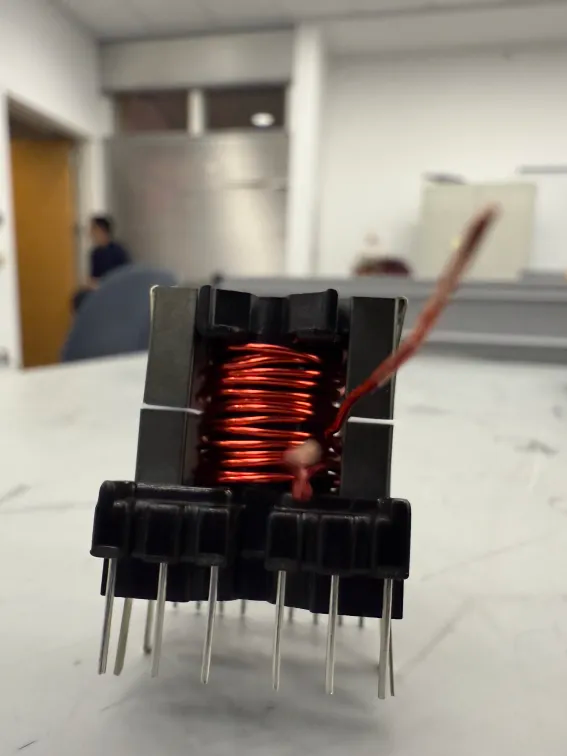
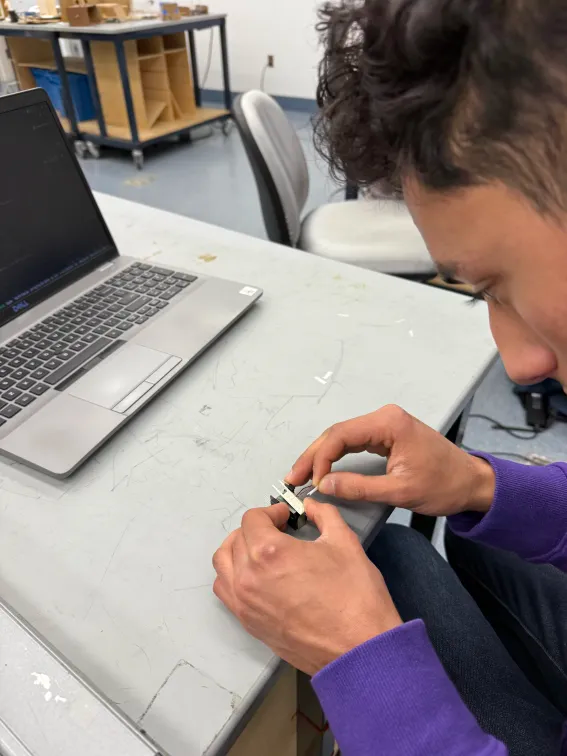
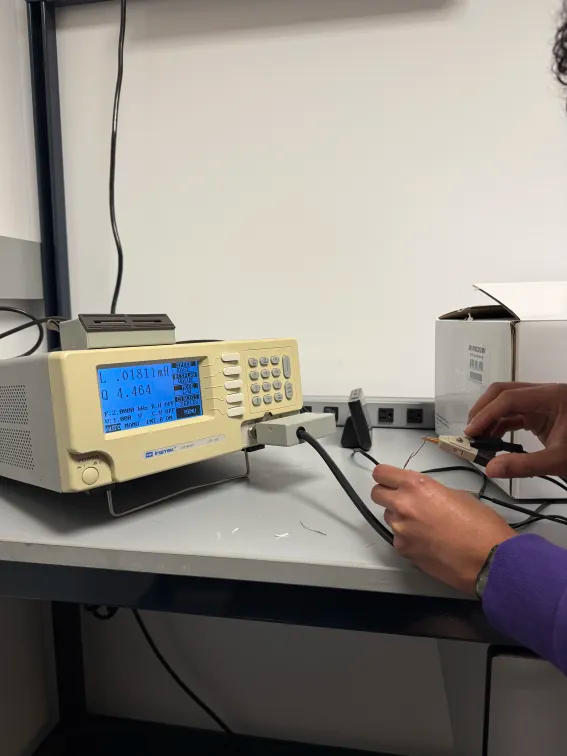


### PLECS Sim

I input the magnetizing inductance and turns ratio in PLECS and simulated with an output of 10V, receiving an output of 10.000V, giving me reasonable confidence that these parameters should work for our lab converter

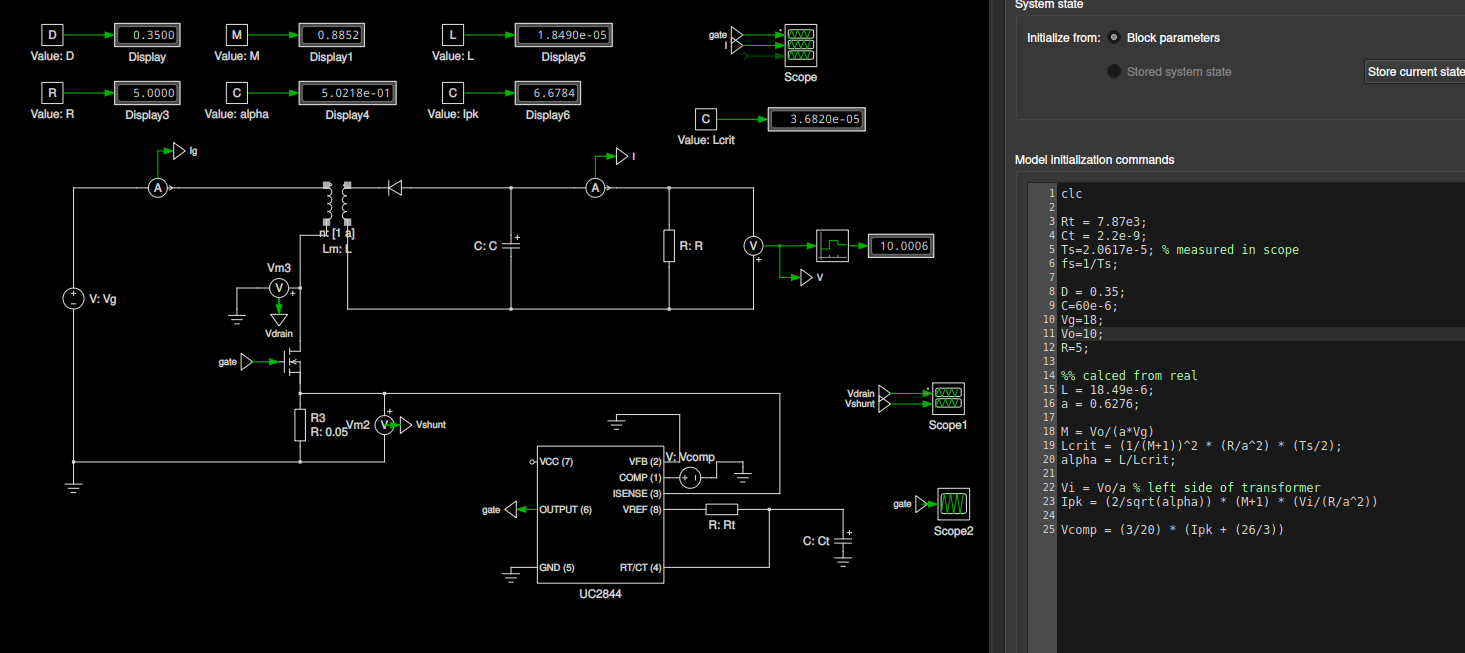

### Drawing

See attached screengrab of drawing

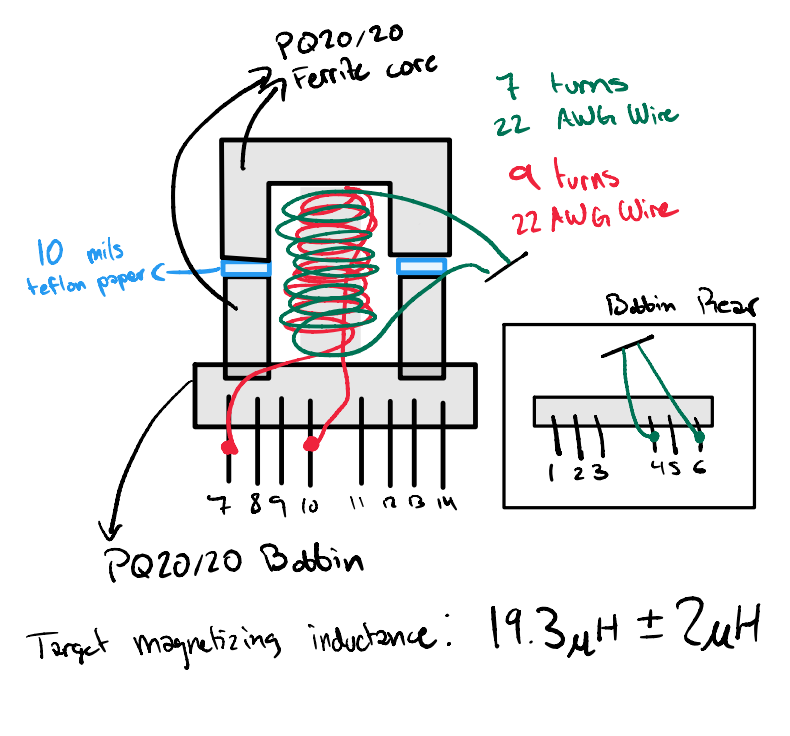

# Lab

In [11]:
# import all the data
v4, _ = import_and_clean('t1_4v', ["Vshunt", "Vdrain"], True, 30)
v7, _ = import_and_clean('t1_7v', ["Vshunt", "Vdrain"], True, 30)
v10, _ = import_and_clean('t1_10v', ["Vshunt", "Vdrain"], True, 30)
hf, _ = import_and_clean('hf_osc', ["_", "Vdrain"], True)
lf, dt = import_and_clean('lf_osc', ["_", "Vdrain"], True)


### Q1/Q3

The below code cell plots our shunt and drain voltages for 4, 7, and 10 V

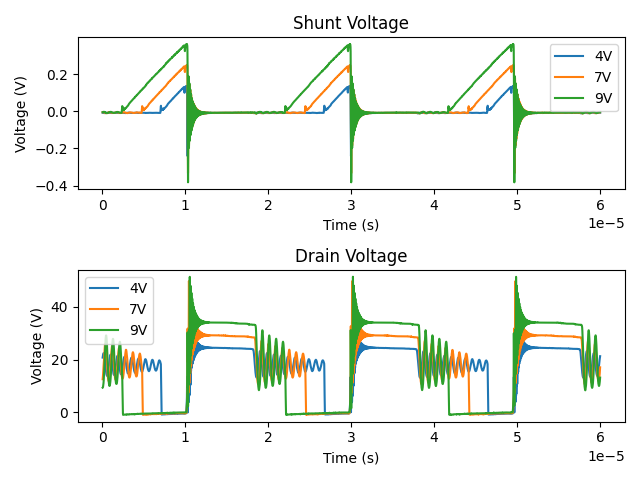

In [12]:
dfs = [v4, v7, v10]

figure, (ax1, ax2) = plt.subplots(2,1)
for df in dfs:
    df.plot(x="X", y="Vshunt", ax=ax1, title="Shunt Voltage")
    df.plot(x="X", y="Vdrain", ax=ax2, title="Drain Voltage")

ax1.legend(["4V", "7V", "9V"])
ax2.legend(["4V", "7V", "9V"])
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
figure.tight_layout()

### Q2

The below table shows our output voltages, and supplied current for each of the three tests

| Output Voltage | Input Current |
| -------------- | ------------- |
| 4.01V          | 0.27 A        |
| 7.01V          | 0.75 A        |
| 10.06V         | 1.5 A         |

### Q4

The below code cell plots our high frequency oscillations at FET Turn-off at an output of 10.01V

Text(0, 0.5, 'Voltage (V)')

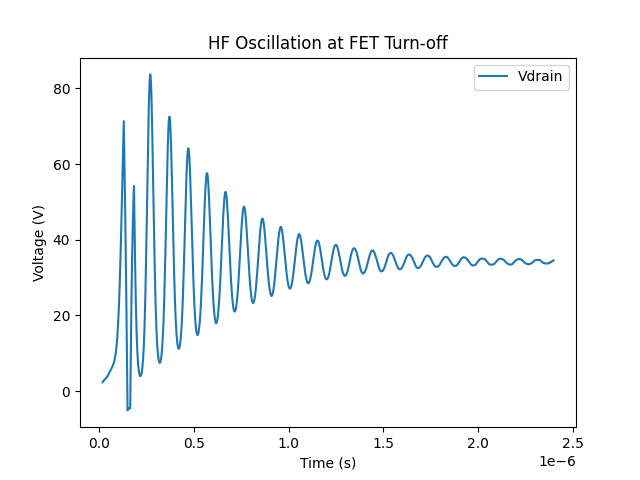

In [13]:
fig, ax = plt.subplots()
hf.plot(x="X", y="Vdrain", ax=ax, title="HF Oscillation at FET Turn-off")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")


### Q5

The below code cell plots our low frequency oscillations at diode turn-off at an output of 10.01V

Text(0, 0.5, 'Voltage (V)')

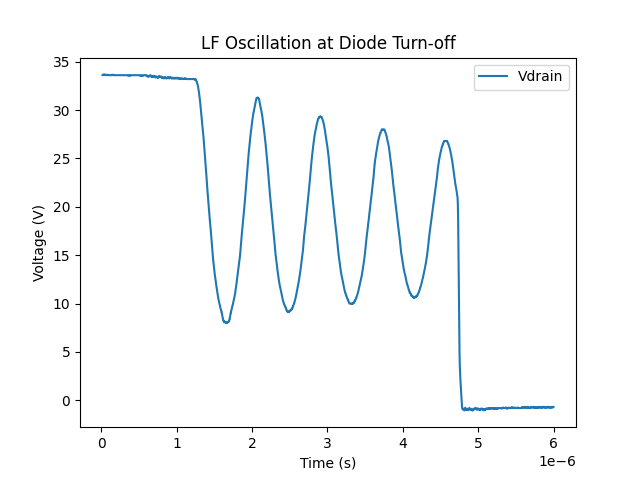

In [14]:
fig, ax = plt.subplots()
lf.plot(x="X", y="Vdrain", ax=ax, title="LF Oscillation at Diode Turn-off")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

### Q6

The below code cells calculate our mean magnetizing inductance and mean turns ratio across all of our tests. The inductance (18.49 uH) is somewhere between our LCR measured value (about 18.11 uH) and our calculated expected value (19.3 uH).

The turns ratio is slightly further off - we experimentally calculatd about 0.62 for our turns ratio, but our design of 9:7 turns should have a ratio of closer to 0.77. We suspect imperfect manufacturing may be the root cause of this, however given that the rest of our transformer still performs within the specifications, we think it should still be usable for the purposes of our flyback converter.

In [15]:
ts = [(2.71e-5, 2.93e-5), (2.49e-5, 2.93e-5), (2.25e-5, 2.93e-5)]
Vs = [4.01, 7.01, 10.06]
Ls = []

for df, t, V in zip(dfs, ts, Vs):
    Ls.append(L := calc_inductance(df, *t, VG)) 
    print(f"Magnetizing inductance at output voltage of {V}V: {round(L * 10e5, 3)} uH")
print(f"Mean Inductance: {round((Lmean := np.mean(Ls)) * 10e5, 3)} uH")

Magnetizing inductance at output voltage of 4.01V: 18.206 uH
Magnetizing inductance at output voltage of 7.01V: 18.474 uH
Magnetizing inductance at output voltage of 10.06V: 18.789 uH
Mean Inductance: 18.49 uH


In [16]:
drains = [24.5, 29, 34]
turn_ratios = []

for drain, V in zip(drains, Vs):
    turn_ratios.append(a := (V / (drain - VG)))
    print(f"Transformer turn ratio at output voltage {V}V is {round(a, 4)}")

print(f"Mean Turns Ratio: {round(a_mean := np.mean(turn_ratios), 4)}")

Transformer turn ratio at output voltage 4.01V is 0.6169
Transformer turn ratio at output voltage 7.01V is 0.6373
Transformer turn ratio at output voltage 10.06V is 0.6288
Mean Turns Ratio: 0.6276


### Q7

To check that our inductor is within spec, we must verify our alpha and duty cycle. Our alpha was measured to be about 0.66 in Q6, so that is within the 0.6 to 0.7 requirement. The below cell calculates our duty cycle at 10V to be 38.7%, which is about 5% off from our calculated value, and 3% away from the specification of 35%, which we believe is far enough from the 50% duty cycle limiter to be usable to control our converter. Therefore, we are not making any adjustments to our transformer at this time.

In [17]:
# calculate duty cycle
print(*(Ds := [f"{round(duty_cycle(x, 'Vdrain', 2.1e-5, 3.1e-5) * 100, 2)}%" for x in [v4, v7, v10]]))

15.08% 26.64% 38.72%


### Q8

We do have some deviations from our calculated expected parameters of our transformer - particularly, our turns ratio experimentally seems to be about 0.63, when we would have expected something closer to $7/9 = 0.77$. The number we got aligns more with a ratio of $6/9 = 0.67$, so it's possible we may have accidentally lost a turn in our seconday winding, perhaps when moving it to the right position to solder it in. Regardless, because the rest of our transformer appeared to be functioning within the acceptable operating windows, we are not making any adjustments to it at this time.

### Q9

The below code cell plots the two ringing waveforms, the next calculates the frequencies, and the last calculates the damping ratios.

For both, I trimmed the waveform to just a section of the oscillation, used the scipy.find_peaks() function to find the peaks, then took the distance between them to find the frequency. The plots with the peaks annotated are shown below.

High frequency: 10_221_465.076660989 Low frequency: 1_202_886.9286287087


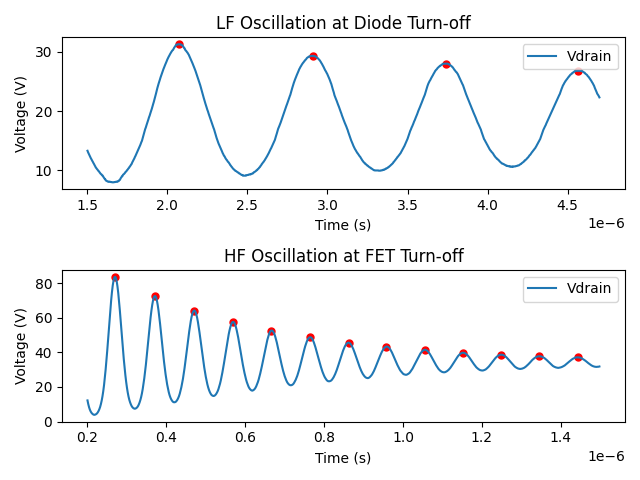

In [18]:
hf_time = hf[(hf['X'] > 2e-7) & (hf['X'] < 1.5e-6)]
lf_time = lf[(1.5e-6 < lf['X']) & (lf['X'] < 4.7e-6)]
hf_peaks, hf_f = frequency(hf_time["Vdrain"], dt, 0.8, 10)
lf_peaks, lf_f = frequency(lf_time["Vdrain"], dt, 0.8, 100)

fig, (ax1, ax2) = plt.subplots(2,1)
lf_time.plot(x='X', y='Vdrain', ax=ax1, title="LF Oscillation at Diode Turn-off")
lf_time.iloc[lf_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax1, s=25, c='red')
hf_time.plot(x='X', y='Vdrain', ax=ax2, title="HF Oscillation at FET Turn-off")
hf_time.iloc[hf_peaks].plot(x='X', y='Vdrain', kind='scatter', ax=ax2, s=25, c='red')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
fig.tight_layout()
print(f'High frequency: {hf_f:_}', f'Low frequency: {lf_f:_}')

For the damping ratio, I went through each consecutive set of peaks and applied the following formulas from the lab to find the damping ratio, then averaged my results to come up with a mean damping ratio for the HF and LF oscillation of about 0.011 and 0.008 respectively

$$
\delta = \frac{1}{n} \ln{\frac{x_1}{x_{n+1}}}
$$

and 

$$
\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}
$$

In [19]:
for df, peaks in zip([hf_time, lf_time], [hf_peaks, lf_peaks]):
    peak_vals = np.array(df["Vdrain"].iloc[peaks])
    delta = np.mean(np.log(peak_vals[:-1] / peak_vals[1:]))
    zeta = delta / np.sqrt(4*np.pi**2 + delta**2)
    print(zeta)

0.010780053178546503
0.0082002903128676


### Q10

According to Q7, we have calculated the duty cycle and found it to be 38.7% for a 10V output, which matches close enough with the expected 35%. 

The code cell calcualtes the current density to be 7.98 Arms / mm^2, which is below the 10 Arms / mm^2 maximum using the equation

$$
\text{Current Density} = \frac{i_{rms}}{\text{Wire Cross-sectional area}}
$$

where $i_{rms} = \sqrt{\frac{D}{3}} * i_{pk}$ per the lecture notes


In [20]:
irms = sqrt(0.387/3) * Ipk
awg22_a = 0.326
print(f"RMS Current density {round(irms / awg22_a, 2)} A/mm^2")

NameError: name 'Ipk' is not defined

### Q11

Based on Q6 and Q7, we have established based on our lab measurements of an inductance of 18.48 uH that our magnetizing inducatance and therefore inductance ratio $\alpha$ are within the specified transformer requirements. The below code cell calcaultes our flux density as about 0.25T, which is below the 0.3T maximum using the equation

$$
B = \frac{L*I_{pk}}{A{cmin} * N}
$$

Where N is the primary winding turn number.


To verify our alpha, in the below code cell, we used the equation from the buck-boost converter notes:

$$
\alpha = (D * \frac{M+1}{M})^2
$$

Where $\frac{M+1}{M}$ is the CCM duty cycle, and D is our measured DCM duty cycle from our scope plots. This calculation gave us an alpha of 0.68, which is within our desired spec of 0.6-0.7

In [ ]:
Ish = v10["Vshunt"].dropna() / R_SHUNT
Ipk = max(Ish)
print(f"Ipk: {round(Ipk,2)}A")
B = (Lmean * Ipk) / (Ac * n1)
print(f"Flux Density: {round(B,4)}T")


M = Vo / (a_mean * VG)
D10 = 0.3872
alpha = (D10 * ((M+1)/M))**2
print(f"alpha: {round(alpha, 3)}")

Ipk: 7.24A
Flux Density: 0.2517T
alpha: 0.68
